In [4]:
# fix relative imports
import os
cwd = os.path.normpath(os.getcwd())
cwd = cwd.split(os.sep)
find = cwd.index("fidelity-phase-tran")
newdir = f"{os.sep}".join(cwd[:find+1])
os.chdir(newdir)
%load_ext autoreload
%autoreload 2

# import known packages
# import numpy as np
import pickle
import gzip
import numpy as np

from matplotlib import pyplot as plt

# from scipy import signal

from tenpy.networks.mps import MPS

# import adhoc packages
from qphaset.phases import gstates_to_rdms_matrix, gstates_to_rdms_matrix_qs_mps, phases_vfield, generalized_k_rdm
from qphaset.models import get_bond_dim_qs_mps
from qphaset.plotting import plot_grad_g_angle_stream, plot_grad_g_angle4, plot_grad_g_angle_sin_cos

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# choose which tensor network package to use:

# tnpy, qsmps = True, False
tnpy, qsmps = False, True

## Phase transitions detection
Implemementation of one of the main results of the paper.

In [82]:
"""
Type of filename to use:
filename = 'results/data/{model}_{identifier}.pkl'
"""
# filename = 'results/annni-20spins-64x64-dmrg-20240212.pkl'             # First decent ANNNI 20
# filename = 'results/ising-20spins-64x64-dmrg-20240214.pkl'

# filename = "annni_ext-93346fe8-cf92-4c55-9b47-0cb2b6f25c0c.pkl"        # ANNNI 50, c1=-1, upside down (*)
# filename = "annni_ext-7e477513-fe51-4ee3-9ae3-75766993ae7a.pkl"        # ANNNI 50, c1=h-1, upside down
# filename = "annni_ext-5234439f-02a3-4e3a-8c6a-a5d0a670dd0c.pkl"        # ANNNI 50, c1=-1, upside down, floating detail
# filename = "annni_ext-d02bd810-dece-40b1-8e36-ac6c8164bb46.pkl"        # ANNNI 50, c1=-0.1, upside down, floating detail
# filename = "annni_ext-aba4d4c0-cb6f-454b-b2e4-8babb3be68b6.pkl"        # ANNNI 50, c1=0, upside down, floating detail, 16 x 16
# filename = "annni_ext-0b44047c-884a-42b9-8bfe-bc5beb29be96.pkl"        # ANNNI 30, c1=0, upside down, floating detail, 32 x 32

# Effects of the grid coarse on the floating phase.
# filename = "annni_ext-b00ffcec-f325-4f18-b5d8-e15111ee72fb.pkl"            # ANNNI 30, c1=-0.1, upside down, floating detail, 32 x 32 (*)
# filename = "annni_ext-a76f14e2-354c-4588-a698-5d7cdaef11ec.pkl"            # ANNNI 30, c1=-0.1, upside down, floating detail, 64 x 64 (*)
# filename = "annni_ext-c47e7c80-227f-4b18-b8a4-c910cc6d6908.pkl"            # ANNNI 50, c1=-1, upside down, floating detail, 64 x 64 (**)
filename = "annni_ext-b9e5a93e-f105-411d-8013-b3120de2b88e.pkl"            # ANNNI 50, c1=-1, upside down, floating detail + multi-critical point, 64 x 64 (**)

# filename = "annni_ext-516fe606-16d0-4bce-afd0-5af6fb262d91.pkl"              # ANNNI 50, c1=-1, upside down, floating detail ++ (**)
# filename = "annni_ext-fad679a7-c06a-4112-8f28-97c92414d43b.pkl"                # ANNNI 30, c1=-1, upside down, floating detail ++ (**)

# filename = "annni_ext-297aa19b-e072-4ec5-b9fc-718bf75db45e.pkl"             # ANNNI 16, c1=-1, upside down, 64 x 64
# filename = "annni_ext-e810f2eb-6837-48a9-a2c7-7acd305f5e70.pkl"             # ANNNI 20, c1=-1, upside down, 64 x 64 (*)

# francesco's qs-mps results
filename = "results/data/ANNNI-7902ff06-aac2-4fab-ac2a-2692af269fd4.pkl" # ANNNI 12, c1=-1, upside down, 64 x 64
# filename = "results/data/ANNNI-8fad8665-b3af-43a1-be1b-c27fa8b42920.pkl"
filename = "results/data/ANNNI-8e2b8bce-1d27-41d0-a48b-fbce8d4ab8cc.pkl" # ANNNI 50, c1=-1, upside down, 64 x 64
# filename = "results/data/ANNNI-163e02cf-c141-41c4-9f54-8f5dbeb10b7a.pkl" # ANNNI 10, c1=-1, upside down, 64 x 64, floating detail
# filename = "results/data/ANNNI-7474d9df-a970-4b6c-8fb7-3578e77c5d97.pkl" # ANNNI 10, c1=-1, upside down, 20 x 20, all phase diagram
# filename = "results/data/ANNNI-010201b6-5ab8-45af-9e50-507c9b609272.pkl" # if we truncate the bond dimension dmrg finds a product state, we can only see the disorder line


filename = "results/data/Cluster-17d83de7-f497-4403-8306-5aee3bafad5f.pkl" # Cluster 10, c1=-1, upside down, 10 x 10
filename = "results/data/Cluster-9b763977-c15f-48c6-b384-dbb7adad65bf.pkl" # Cluster 10, c1=1e-3, upside down, 10 x 10
filename = "D:/code/projects/3_CLUSTER/results/data/Cluster-b0dcc0d6-4524-40ba-a7e0-562f68485c59.h5" # cluster 10, c1=1e-3, upside down, 10 x 10
filename = "D:/code/projects/3_CLUSTER/results/data/Cluster-90a28ad9-2dde-425c-acb4-c67f55b259ef.h5" # cluster 10, c1=1e-3, upside down, 20 x 20
import os
from tenpy.tools import hdf5_io
import h5py

# Specify the directory containing your files
directory = 'D:/code/projects/3_CLUSTER/results/data'

# List all files in the directory
files = os.listdir(directory)

# Filter for .pkl and .h5 files
pkl_and_h5_files = [os.path.join(directory, file) for file in files if file.endswith('.pkl') or file.endswith('.h5')]

# Print the list of file names
for file in pkl_and_h5_files:
    print(f"File: {file} has these metadata:")
    if file.endswith('.pkl'):
        with gzip.open(file, 'rb') as f:
            data = pickle.load(f)
            params = data['params']
            l, n = data['l'], data['n']
            gstates = data['gstates']
            stats = data['stats']
            # model = data['model_name']
        params_extent = np.concatenate([np.min(params, axis=0), np.max(params, axis=0)])
        params_extent = tuple(params_extent[[0, 2, 1, 3]])
    
    if file.endswith('.h5'):
        with h5py.File(file, "r") as f:
            data = hdf5_io.load_from_hdf5(f)
            params_extent = data['params_extent']
            l, n = data['l'], data['n']
            gstates = data['gstates']
            model = data['info']['model_type']
            times = data['times']

    print(f"Model: {model}, Chain length: {l}, points in the grid per side: {n}")
    print(f"Param_extent: {params_extent}")
    print(f"\n#############################\n\n")



File: D:/code/projects/3_CLUSTER/results/data\Cluster-b0dcc0d6-4524-40ba-a7e0-562f68485c59.h5 has these metadata:
Model: Cluster, Chain length: 10, points in the grid per side: 10
Param_extent: (0.1, 1.5, 0.1, 1.5)

#############################


File: D:/code/projects/3_CLUSTER/results/data\Cluster-90a28ad9-2dde-425c-acb4-c67f55b259ef.h5 has these metadata:
Model: Cluster, Chain length: 10, points in the grid per side: 20
Param_extent: (0.1, 0.3, 0.1, 0.3)

#############################


File: D:/code/projects/3_CLUSTER/results/data\Cluster-f1b9c7c9-f517-4680-94ca-e79f6bd1649f.h5 has these metadata:
Model: Cluster, Chain length: 10, points in the grid per side: 20
Param_extent: (0.1, 0.3, 0.1, 0.3)

#############################


File: D:/code/projects/3_CLUSTER/results/data\Cluster-6b22eed9-1e68-4cd0-a41c-f904407b657b.pkl has these metadata:
Model: Cluster, Chain length: 12, points in the grid per side: 30
Param_extent: (0.1, 1.5, 0.1, 1.5)

#############################




In [83]:
import types
if isinstance(gstates[0], (types.BuiltinFunctionType, types.BuiltinMethodType)):
    gstates = [gstate() for gstate in gstates]

In [84]:
# Select sites for the partial trace (gstates -> rdms, ie ground states to reduced density matrices).
# Note the concept of site depends on the model. For example in the case of models based on the
# class SpinChainNNN, the site corresponds to 2 qubits.

sites = [(l // 2) - 2, (l // 2) - 1, l // 2, (l // 2) + 1, (l // 2) + 2]
sites = [(l // 2) - 1, l // 2, (l // 2) + 1]
# sites = [l // 2, (l // 2) + 1]
# sites = [l // 2]

if tnpy:
    rdms = gstates_to_rdms_matrix(gstates, sites=sites)
elif qsmps:
    rdms = gstates_to_rdms_matrix_qs_mps(gstates, sites=sites, generalized=True)

In [88]:
# TODO Fix this in the DMRG runs.
rdms = rdms[::-1]

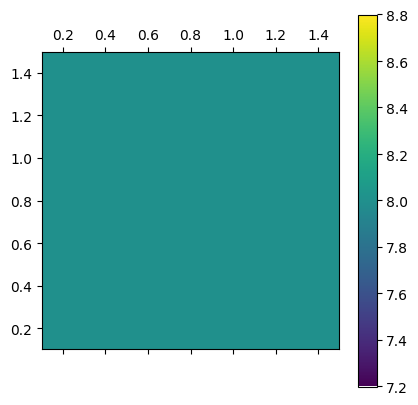

In [89]:
# Plot RDMs ranks. This is useful to study the problem of the singularities
# of the Quantum Fisher Information Matrix.

rdm_ranks = np.reshape(rdms, (-1, ) + rdms.shape[2:])
rdm_ranks = [np.linalg.matrix_rank(mat, hermitian=True) for mat in rdm_ranks]
rdm_ranks = np.reshape(rdm_ranks, rdms.shape[:2])
plt.matshow(rdm_ranks, origin='lower', extent=params_extent)
plt.colorbar()

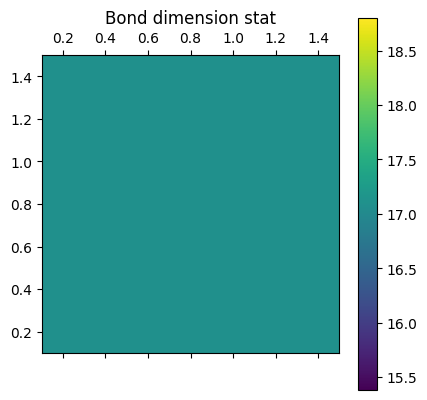

In [90]:
# Plot bond dimension.
if tnpy:
    bond_dim_map = np.array([np.mean(psi.chi) for psi in gstates])
    bond_dim_map = bond_dim_map.reshape((n, n))
    plt.matshow(bond_dim_map, origin='lower', extent=params_extent)
    plt.title('Bond dimension stat')
    plt.colorbar()
elif qsmps:
    # TODO for now we save arrays instead of objects of the class MPS
    bond_dim_map = np.array([np.mean(get_bond_dim_qs_mps(psi)) for psi in gstates])
    bond_dim_map = bond_dim_map.reshape((n, n))
    plt.matshow(bond_dim_map, origin='lower', extent=params_extent)
    plt.title('Bond dimension stat')
    plt.colorbar()

In [71]:
eps = params[1, 0] - params[0, 0]
eps

0.04827586206896553

In [ ]:
# Plot execution time per pixel (DMRG runtime).

plt.matshow(np.array(stats['times']).reshape((n, n))[::-1], cmap='hot', origin='lower', extent=params_extent)
plt.colorbar()

In [91]:
# Grad laplacian filter with upsampling
grad_g = phases_vfield(rdms)
# TODO review params_extent, consider coordinates shift.

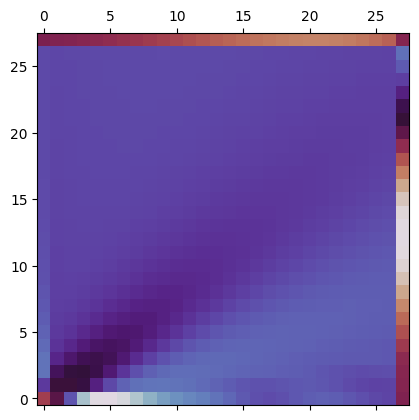

In [92]:
# *** Scaling behaviour (experimental) ***

dlog_g = phases_vfield(rdms, log_g=True, scale=1)

from qphaset.models import params_2d_lattice
xy = params_2d_lattice(params_extent[:2], params_extent[2:], n=len(dlog_g))
xy = np.reshape(xy, (len(dlog_g), ) * 2 + (2, ))
# TODO Double check real/imag association with x, y!
nu = xy[:, :, 0] * np.real(dlog_g) + xy[:, :, 1] * np.imag(dlog_g)

# Note the values should not be interpreted directly since the numerical derivative
# is mul by some const factor.
plt.matshow(nu, origin='lower', cmap='twilight')

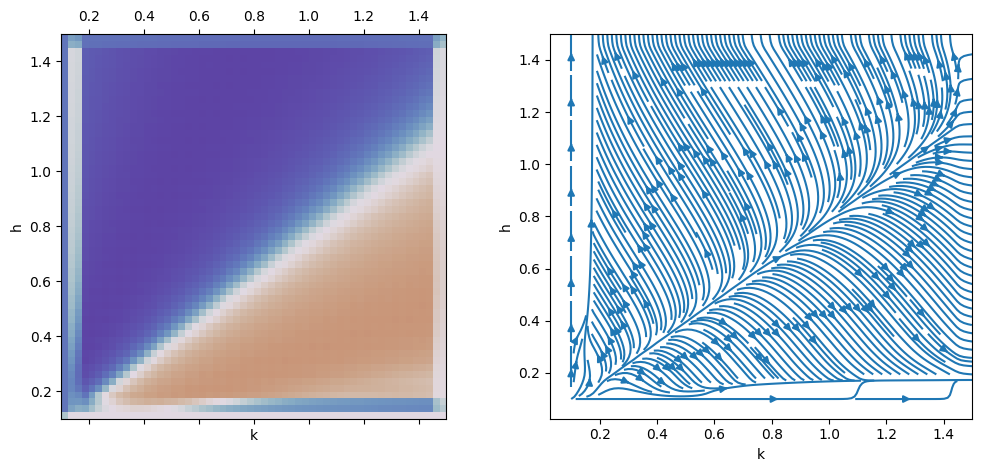

In [93]:
plot_grad_g_angle_stream(grad_g, params_extent=params_extent, theory_lines=False);

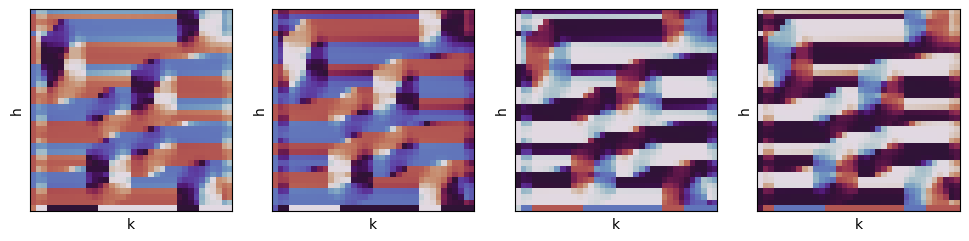

In [31]:
plot_grad_g_angle4(grad_g, params_extent=params_extent);

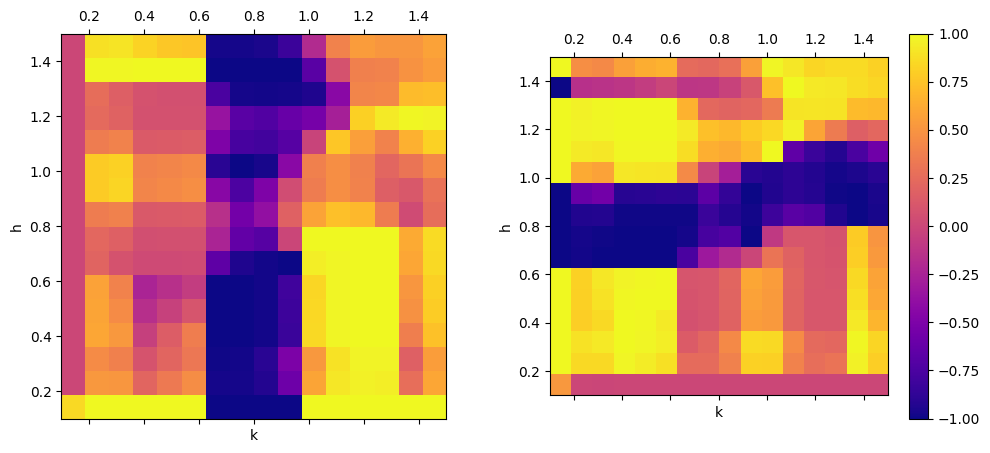

In [19]:
plot_grad_g_angle_sin_cos(grad_g, params_extent=params_extent);